# SPbGU AFM U-Net pipeline

Сбор manifest, обучение U-Net, k-fold валидация и экспорт масок/оверлеев для АСМ.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """Find repository root from known local path or parent directories."""
    known_roots = [Path(r'D:/Nornikel-2026-Shlif-Case')]
    start = (start or Path.cwd()).resolve()
    markers = [
        Path('configs') / 'segmentation' / 'spbgu_unet.json',
        Path('models') / 'segmentation.py',
    ]
    for candidate in [*known_roots, start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError('Project root not found. Set PROJECT_ROOT manually to D:/Nornikel-2026-Shlif-Case.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)


D:\Nornikel-2026-Shlif-Case


In [2]:
import torch
from hydra.json_config import JsonConfig

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'segmentation' / 'spbgu_unet.json'
cfg = JsonConfig.load(CONFIG_PATH).to_dict()
print('cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
cfg

cuda: True
NVIDIA GeForce RTX 3060


{'manifest': {'root': 'spbgu_data',
  'output_csv': 'artifacts/manifests/spbgu_segmentation_manifest.csv',
  'input_kind': 'txt',
  'val_fraction': 0.25,
  'seed': 42},
 'training': {'seed': 42,
  'device': 'auto',
  'dataset_csv': 'artifacts/manifests/spbgu_segmentation_manifest.csv',
  'run_dir': 'notebooks/spbgu_unet_experiments/outputs/runs/spbgu_unet_resnet34_txt',
  'data': {'image_size': 512,
   'batch_size': 2,
   'num_workers': 0,
   'augment': True},
  'augmentation': {'hflip_p': 0.5,
   'vflip_p': 0.5,
   'max_rotate_degrees': 20,
   'brightness': 0.12,
   'contrast': 0.22,
   'clahe_p': 0.45,
   'noise_p': 0.35,
   'noise_sigma_min': 1.0,
   'noise_sigma_max': 8.0,
   'blur_p': 0.15,
   'blur_kernel_sizes': [3, 5]},
  'model': {'name': 'smp_unet',
   'encoder_name': 'resnet34',
   'encoder_weights': 'imagenet',
   'in_channels': 3,
   'classes': 1},
  'loss': {'bce_weight': 0.35,
   'dice_weight': 0.55,
   'focal_weight': 0.1,
   'focal_alpha': 0.65,
   'focal_gamma': 2.0},

## Manifest

`input_kind='txt'` обучает на NT-MDT ASCII высотных картах. Для эксперимента с jpg-визуализациями можно поставить `cfg['manifest']['input_kind'] = 'jpg'` и синхронно заменить `training.run_dir`.

In [3]:
import pandas as pd
from data.spbgu_segmentation import SpbguSegmentationManifestBuilder

rows = SpbguSegmentationManifestBuilder(cfg['manifest']).build()
df = pd.DataFrame(rows)
display(df)
display(df.groupby(['subset', 'domain_label']).size())

,sample_id,source_path,mask_path,input_kind,domain_label,rel_path,subset
0,9A003_1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_1.bmp,train
1,9A003_3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_3.bmp,train
2,9A003_7,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_7.bmp,train
3,9A003_9,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_9.bmp,val
4,9A005_1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_1.bmp,val
5,9A005_3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_3.bmp,train
6,9A005_7,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_7.bmp,train
7,9A005_9,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_9.bmp,train
8,9S001_1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,rupture,сталь 09Г2С\6_Разрыв\9S001\9S001_1.bmp,train
9,9S001_3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,rupture,сталь 09Г2С\6_Разрыв\9S001\9S001_3.bmp,train


subset  domain_label
train   delivery        6
        rupture         6
val     delivery        2
        rupture         2
dtype: int64

## Sanity check

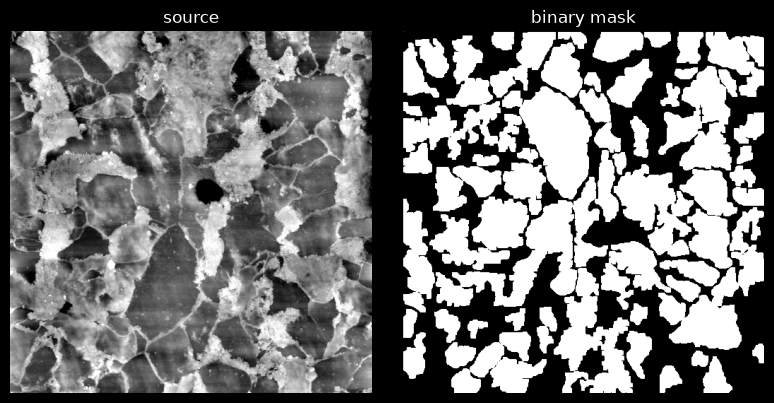

In [4]:
import matplotlib.pyplot as plt
from data.spbgu_segmentation import read_spbgu_binary_mask, read_spbgu_image

sample = df.iloc[0]
image = read_spbgu_image(sample.source_path, sample.input_kind)
mask = read_spbgu_binary_mask(sample.mask_path)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('source')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('binary mask')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## Holdout training

In [ ]:
from trainers.spbgu_unet_trainer import SpbguUNetTrainer

trainer = SpbguUNetTrainer(cfg['training'])
summary = trainer.fit()
summary

spbgu epochs:   0%|          | 0/40 [00:00<?, ?epoch/s]

train spbgu 1:   0%|          | 0/6 [00:00<?, ?batch/s]

val spbgu 1:   0%|          | 0/2 [00:00<?, ?batch/s]

train spbgu 2:   0%|          | 0/6 [00:00<?, ?batch/s]

val spbgu 2:   0%|          | 0/2 [00:00<?, ?batch/s]

...

train spbgu 6:   0%|          | 0/6 [00:00<?, ?batch/s]

val spbgu 6:   0%|          | 0/2 [00:00<?, ?batch/s]

train spbgu 7:   0%|          | 0/6 [00:00<?, ?batch/s]

val spbgu 7:   0%|          | 0/2 [00:00<?, ?batch/s]

train spbgu 8:   0%|          | 0/6 [00:00<?, ?batch/s]

In [ ]:
run_dir = Path(cfg['training']['run_dir'])
history = pd.read_csv(run_dir / 'history.csv')
display(pd.read_json(run_dir / 'best_metrics.json', typ='series'))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history.epoch, history.train_loss, label='train')
axes[0].plot(history.epoch, history.val_loss, label='val')
axes[0].set_title('loss')
axes[1].plot(history.epoch, history.train_dice, label='train')
axes[1].plot(history.epoch, history.val_dice, label='val')
axes[1].set_title('dice')
axes[2].plot(history.epoch, history.train_iou, label='train')
axes[2].plot(history.epoch, history.val_iou, label='val')
axes[2].set_title('iou')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()

## Prediction overlays

In [ ]:
from visualization.spbgu_segmentation import SpbguMaskPredictor

predictor = SpbguMaskPredictor(run_dir / 'best.pt')
predictor.save_manifest_predictions(
    cfg['prediction']['manifest_csv'],
    cfg['prediction']['output_dir'],
    threshold=cfg['prediction']['threshold'],
)
print(cfg['prediction']['output_dir'])

## Cross-validation

Запускай после holdout, если нужно подтвердить устойчивость модели. На текущем SPbGU наборе по умолчанию 4 fold, потому что грубых доменных групп всего две и данных мало.

In [ ]:
RUN_CV = False
if RUN_CV:
    from trainers.spbgu_unet_trainer import SpbguCrossValidator
    cv_result = SpbguCrossValidator(cfg['training']).run()
    print(cv_result)
    cv_dir = Path(cv_result['run_dir'])
    display(pd.read_csv(cv_dir / 'cv_metrics.csv'))
    display(pd.read_json(cv_dir / 'cv_summary.json').T)